## E3

### Mision 1: Preparacion del conjunto de datos
Cargue el archivo E3 datos.csv, inspeccione sus variables y prepare una matriz de caracteristicas adecuada para el analisis. Debe tratar los valores faltantes, transformar las variables categoricas que corresponda y construir al menos tres variables derivadas que ayuden a representar mejor las caracteristicas de cada distrito. Justifique brevemente las decisiones tomadas en esta etapa.


In [1]:
import pandas as pd

df = pd.read_csv("E3_datos.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [3]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

dropeamos la median_house_value porque es la variable objetivo, y no queremos que esta influya en el proceso de entrenamiento del modelo. En cuanto a los valores faltantes, decidimos imputar la mediana para las variables numéricas, ya que es una medida robusta frente a los valores atípicos.

In [4]:
y = df["median_house_value"]
X = df.drop(columns=["median_house_value"])

In [5]:
X["total_bedrooms"] = X["total_bedrooms"].fillna(X["total_bedrooms"].median())

In [6]:
X.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

In [7]:
X["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Para las 3 variables derivadas, decidimos crear las siguientes:

1. rooms_per_household: Esta variable representa la cantidad de habitaciones por hogar, lo que puede ser un indicador de la calidad de vida en el distrito.
2. bedrooms_per_room: Esta variable representa la proporción de dormitorios por habitación, lo que puede indicar la distribución del espacio en las viviendas.
3. population_per_household: Esta variable representa la cantidad de personas por hogar, lo que puede ser un indicador de la densidad poblacional y las condiciones de vida en el distrito.

Básicamente, estas variables derivadas nos permiten capturar aspectos importantes de la vivienda y la población que podrían influir en el valor de las propiedades en cada distrito.

In [8]:
X["rooms_per_household"] = X["total_rooms"] / X["households"]
X["bedrooms_per_room"] = X["total_bedrooms"] / X["total_rooms"]
X["population_per_household"] = X["population"] / X["households"]

X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY,6.281853,0.172096,2.181467


In [9]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Columnas numéricas:")
print(num_cols)

print("Columnas categóricas:")
print(cat_cols)

Columnas numéricas:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'rooms_per_household', 'bedrooms_per_room', 'population_per_household'],
      dtype='object')
Columnas categóricas:
Index(['ocean_proximity'], dtype='object')


Vamos a ver más o menos los valores únicos de las numéricas para ver si realmente lo son y no una categórica encubierta, como puede ser un año, por ejemplo.

In [10]:
for col in num_cols:
    print(f"Value counts para {col}:")
    print(X[col].value_counts())
    print("\n")

Value counts para longitude:
longitude
-118.31    162
-118.30    160
-118.29    148
-118.27    144
-118.32    142
          ... 
-123.54      1
-115.94      1
-115.99      1
-116.81      1
-123.71      1
Name: count, Length: 844, dtype: int64


Value counts para latitude:
latitude
34.06    244
34.05    236
34.08    234
34.07    231
34.04    221
        ... 
41.01      1
41.36      1
41.13      1
40.30      1
35.88      1
Name: count, Length: 862, dtype: int64


Value counts para housing_median_age:
housing_median_age
52.0    1273
36.0     862
35.0     824
16.0     771
17.0     698
34.0     689
26.0     619
33.0     615
18.0     570
25.0     566
32.0     565
37.0     537
15.0     512
19.0     502
27.0     488
24.0     478
30.0     476
28.0     471
20.0     465
29.0     461
31.0     458
23.0     448
21.0     446
14.0     412
22.0     399
38.0     394
39.0     369
42.0     368
44.0     356
43.0     353
40.0     304
13.0     302
41.0     296
45.0     294
10.0     264
11.0     254
46.0     

Ahora vamos a encodear y escalar las variables categóricas y numéricas respectivamente, para que el modelo pueda procesarlas de manera adecuada. Para las variables categóricas, utilizaremos One-Hot Encoding, y para las variables numéricas, aplicaremos StandardScaler para normalizarlas.

Les presento otra forma de preparar la matriz de características, utilizando ColumnTransformer para aplicar las transformaciones de manera más eficiente y organizada. Esto nos permitirá manejar tanto las variables numéricas como las categóricas en un solo paso, facilitando el proceso de preparación de los datos para el análisis y modelado posterior.

In [11]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer( # por si quieren usarlo y hacer todo de una, puede ser este
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

In [12]:
# si no, como siempre. Igual la diferencia es que despues de todo esto, el resultado es un array de numpy, 
# no un dataframe de pandas, pero es lo mismo, solo que no tiene los nombres de las columnas.

# from sklearn.preprocessing import StandardScaler
# import pandas as pd

# scaler = StandardScaler()
# X_num = scaler.fit_transform(X[num_cols])

# X_cat = pd.get_dummies(X[cat_cols], drop_first=False)

# X_processed = pd.concat(
#     [pd.DataFrame(X_num, columns=num_cols), X_cat],
#     axis=1
# )

In [13]:
X_processed

array([[-1.32783522,  1.05254828,  0.98214266, ...,  0.        ,
         1.        ,  0.        ],
       [-1.32284391,  1.04318455, -0.60701891, ...,  0.        ,
         1.        ,  0.        ],
       [-1.33282653,  1.03850269,  1.85618152, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.8237132 ,  1.77823747, -0.92485123, ...,  0.        ,
         0.        ,  0.        ],
       [-0.87362627,  1.77823747, -0.84539315, ...,  0.        ,
         0.        ,  0.        ],
       [-0.83369581,  1.75014627, -1.00430931, ...,  0.        ,
         0.        ,  0.        ]])

In [14]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("columnas numericas:")
print(num_cols)

print("cantidad numericas:", len(num_cols))

print("columnas categoricas:")
print(cat_cols)

print("cantidad categoricas:", len(cat_cols))

columnas numericas:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'rooms_per_household', 'bedrooms_per_room', 'population_per_household'],
      dtype='object')
cantidad numericas: 11
columnas categoricas:
Index(['ocean_proximity'], dtype='object')
cantidad categoricas: 1


### Mision 2: Construccion de perfiles no supervisados. 
Construya perfiles de distritos utilizando tecnicas de aprendizaje no supervisado. Para esto, aplique reduccion de dimensionalidad y clustering sobre un conjunto de variables que no incluya median house value.
Debe evaluar distintas configuraciones, justificar sus decisiones y caracterizar los perfiles obtenidos a partir de las variables disponibles. La interpretacion puede incluir la mediana del valor de las viviendas, siempre que esta no haya sido utilizada para construir los perfiles.

Revisar las columnas de X y ver que no haya ninguna que se llame median_house_value, para asegurarnos de que no estamos incluyendo la variable objetivo en el proceso de clustering.

In [15]:
X.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'rooms_per_household', 'bedrooms_per_room',
       'population_per_household'],
      dtype='object')

In [16]:
X_processed.shape

(20640, 16)

In [17]:
# X_processed sera la matriz usada para PCA y clustering
X_unsup = X_processed

Ahora vamos a reducir dimensionalidad con PCA

In [18]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_unsup)


Para ver la varianza explicada acumulada, podemos usar cumsum sobre explained_variance_ratio_ del PCA. Esto nos permitirá determinar cuántos componentes principales necesitamos para explicar un porcentaje significativo de la varianza en los datos. 

Por ejemplo, podríamos buscar el número de componentes necesarios para explicar al menos el 90% de la varianza, lo que nos ayudaría a reducir la dimensionalidad sin perder demasiada información relevante.

In [19]:
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

n_components_90 = np.argmax(varianza_acumulada >= 0.90) + 1

print("varianza explicada por componente:")
print(pca_full.explained_variance_ratio_)

print("\nvarianza acumulada:")
print(varianza_acumulada)

print("\nnumero de componentes para explicar al menos 90% de la varianza:")
print(n_components_90)

varianza explicada por componente:
[3.34472974e-01 1.77755367e-01 1.58123743e-01 8.65967346e-02
 7.76628717e-02 5.96620636e-02 4.25871345e-02 2.17514809e-02
 1.52851070e-02 1.12187309e-02 7.75506287e-03 3.88831805e-03
 1.90597104e-03 1.30856848e-03 2.58722416e-05 1.21450876e-18]

varianza acumulada:
[0.33447297 0.51222834 0.67035208 0.75694882 0.83461169 0.89427375
 0.93686089 0.95861237 0.97389748 0.98511621 0.99287127 0.99675959
 0.99866556 0.99997413 1.         1.        ]

numero de componentes para explicar al menos 90% de la varianza:
7


Con 7 componentes ya podemos explicar el 90% de la varianza, lo que nos permite reducir significativamente la dimensionalidad de los datos mientras mantenemos la mayor parte de la información relevante para el análisis de clustering.

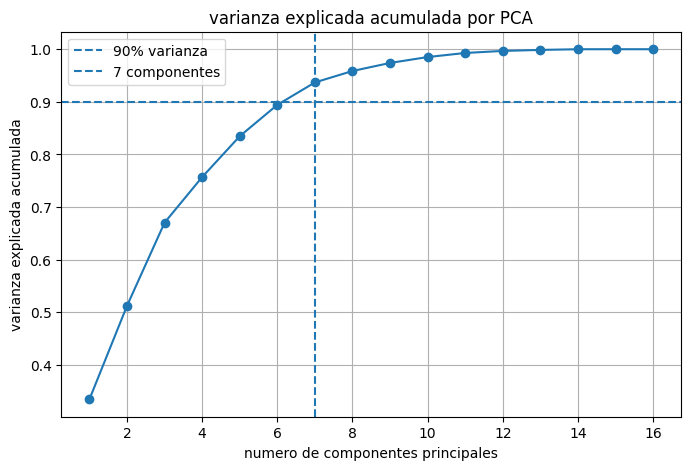

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
    marker="o"
)
plt.axhline(0.90, linestyle="--", label="90% varianza")
plt.axvline(n_components_90, linestyle="--", label=f"{n_components_90} componentes")
plt.xlabel("numero de componentes principales")
plt.ylabel("varianza explicada acumulada")
plt.title("varianza explicada acumulada por PCA")
plt.legend()
plt.grid(True)
plt.show()

Finalmente, 

In [21]:
# PCA final con componentes seleccionados
pca = PCA(n_components=n_components_90)
X_pca = pca.fit_transform(X_unsup)

print("\nDimensión original:", X_unsup.shape)
print("Dimensión después de PCA:", X_pca.shape)


Dimensión original: (20640, 16)
Dimensión después de PCA: (20640, 7)


Ahora vamos a evaluar configuraciones. Lo haremos con inertia y silhouette score, para ver cuál es el número óptimo de clusters.

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

resultados_clustering = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_pca)
    
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_pca, labels)
    print(f"k={k}: Inertia={inertia:.2f}, Silhouette Score={silhouette:.4f}")
    resultados_clustering.append({
        "k": k,
        "inertia": inertia,
        "silhouette": silhouette
    })

resultados_clustering = pd.DataFrame(resultados_clustering)

resultados_clustering

k=2: Inertia=182031.75, Silhouette Score=0.3818
k=3: Inertia=148109.87, Silhouette Score=0.2824
k=4: Inertia=134536.99, Silhouette Score=0.2474
k=5: Inertia=121033.45, Silhouette Score=0.2751
k=6: Inertia=108342.72, Silhouette Score=0.2566
k=7: Inertia=98622.69, Silhouette Score=0.2237
k=8: Inertia=92476.63, Silhouette Score=0.2026
k=9: Inertia=84382.15, Silhouette Score=0.2074
k=10: Inertia=79350.77, Silhouette Score=0.2081


,k,inertia,silhouette
0,2,182031.751021,0.381782
1,3,148109.868619,0.282428
2,4,134536.988224,0.247362
3,5,121033.445558,0.275144
4,6,108342.722721,0.256650
5,7,98622.689231,0.223660
6,8,92476.629695,0.202563
7,9,84382.149069,0.207367
8,10,79350.768506,0.208138


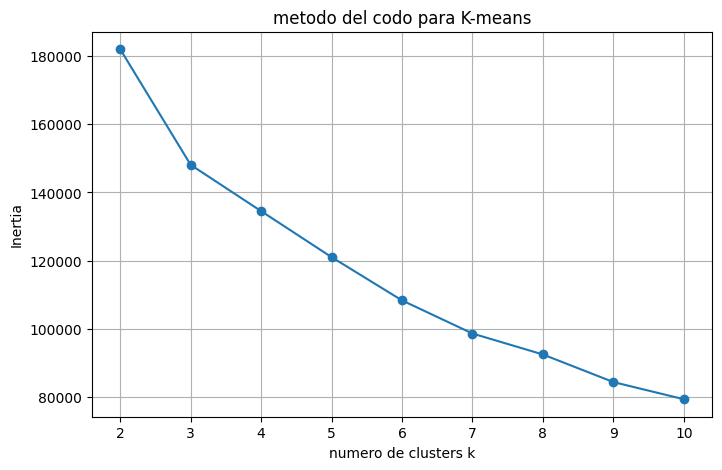

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(
    resultados_clustering["k"],
    resultados_clustering["inertia"],
    marker="o"
)
plt.xlabel("numero de clusters k")
plt.ylabel("Inertia")
plt.title("metodo del codo para K-means")
plt.grid(True)
plt.show()

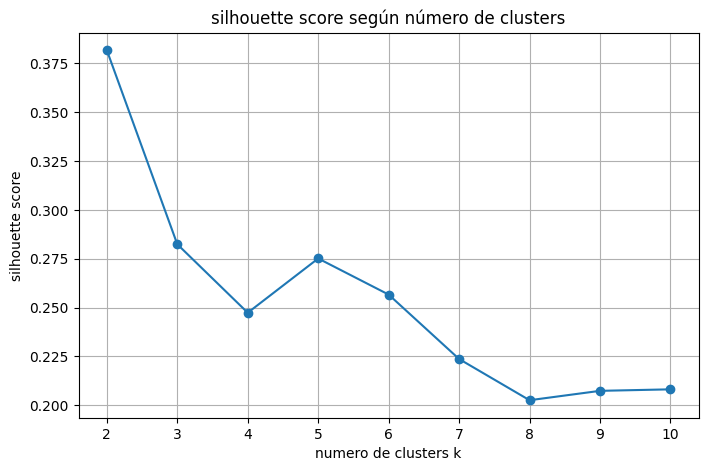

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(
    resultados_clustering["k"],
    resultados_clustering["silhouette"],
    marker="o"
)
plt.xlabel("numero de clusters k")
plt.ylabel("silhouette score")
plt.title("silhouette score según número de clusters")
plt.grid(True)
plt.show()

En base al método del codo y considerando silhouette score, parece que el número óptimo de clusters para nuestro análisis es k=3

In [ ]:
from sklearn.cluster import KMeans

k_final = 3

kmeans_final = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(X_pca)
# una copia para caracterizar perfiles
df_perfiles = X.copy()
df_perfiles["median_house_value"] = y
df_perfiles["cluster"] = clusters

# ver cantidad de distritos por cluster
df_perfiles["cluster"].value_counts().sort_index()

cluster
0    10661
1     1692
2     8287
Name: count, dtype: int64

Finalmente, caracterizamos brevemente.

In [26]:
variables_perfil = [
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
    "median_house_value"
]

perfil_numerico = df_perfiles.groupby("cluster")[variables_perfil].mean().round(2)

perfil_numerico

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household,median_house_value
cluster,,,,,,,,,,
0,29.82,2159.80,454.33,1268.23,426.28,3.90,5.19,0.22,3.12,214982.96
1,16.55,7808.41,1552.13,3966.47,1424.54,4.24,5.59,0.21,2.81,221870.43
2,29.59,2191.96,435.69,1108.97,404.92,3.75,5.70,0.21,3.06,193334.85


Hacemos una tabla de contingencia. 

In [27]:
perfil_oceano = pd.crosstab(
    df_perfiles["cluster"],
    df_perfiles["ocean_proximity"],
    normalize="index"
).round(3)

perfil_oceano

ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
cluster,,,,,
0,0.648,0.194,0.0,0.000,0.157
1,0.463,0.356,0.0,0.079,0.102
2,0.174,0.468,0.0,0.260,0.097


#### Cluster 0: distritos cercanos al océano de valor habitacional medio-alto

El cluster 0 agrupa distritos con una fuerte presencia de zonas cercanas al océano. En particular, un 64,8% de sus observaciones corresponde a la categoría `<1H OCEAN`, mientras que un 15,7% corresponde a `NEAR OCEAN`. Este grupo presenta una antigüedad promedio de viviendas de 29,82 años, un ingreso mediano promedio de 3,90 y un valor mediano de vivienda de aproximadamente 214.983.

En términos habitacionales, este cluster muestra un promedio de 5,19 habitaciones por hogar y una población promedio por hogar de 3,12. Por lo tanto, puede interpretarse como un perfil de distritos costeros o relativamente cercanos al océano, con valores habitacionales medios-altos y características residenciales intermedias.

#### Cluster 1: distritos grandes, más nuevos y de mayor escala habitacional

El cluster 1 representa el perfil con mayor escala poblacional y habitacional. Presenta el mayor promedio de habitaciones totales, con 7.808,41, además del mayor promedio de dormitorios, población y hogares. También corresponde al grupo con viviendas más nuevas, con una antigüedad promedio de 16,55 años.

Este cluster tiene un ingreso mediano promedio de 4,24 y el mayor valor mediano de vivienda entre los tres grupos, aproximadamente 221.870. Además, presenta 5,59 habitaciones por hogar y 2,81 personas por hogar en promedio.

Por estas características, este perfil puede interpretarse como un conjunto de distritos de expansión urbana o zonas residenciales de mayor tamaño, con una escala habitacional más alta y viviendas relativamente más recientes.

#### Cluster 2: distritos interiores o cercanos a la bahía, de menor valor promedio

El cluster 2 agrupa distritos con una mayor presencia de zonas interiores y cercanas a la bahía. Un 46,8% de sus observaciones pertenece a la categoría `INLAND`, mientras que un 26,0% corresponde a `NEAR BAY`. Este perfil presenta una antigüedad promedio de viviendas de 29,59 años, un ingreso mediano promedio de 3,75 y el menor valor mediano de vivienda entre los tres clusters, aproximadamente 193.335.

En términos habitacionales, este grupo tiene el mayor promedio de habitaciones por hogar, con 5,70, y una población promedio por hogar de 3,06. En conjunto, puede interpretarse como un perfil de distritos más interiores o asociados a zonas de bahía, con menor valorización habitacional promedio en comparación con los otros perfiles.

#### Síntesis de perfiles

Los tres clusters permiten distinguir perfiles generales de distritos según características territoriales, habitacionales y socioeconómicas. El cluster 0 se asocia principalmente a distritos cercanos al océano con valor habitacional medio-alto; el cluster 1 representa distritos de mayor escala, más nuevos y con mayor valor promedio; mientras que el cluster 2 agrupa distritos más interiores o cercanos a la bahía, con menor valorización promedio.

### Mision 3: Modelo supervisado base
Construya un modelo supervisado base para predecir median house value. Para esto, entrene y evalue al menos dos modelos de regresion, utilizando metricas adecuadas para comparar su desempeño. En esta mision no debe utilizar informacion generada en la etapa no supervisada. El objetivo es obtener
una linea base para la comparacion posterior

In [28]:
from sklearn.model_selection import train_test_split

X_base = X.copy()
y_base = y.copy()

X_base.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'rooms_per_household', 'bedrooms_per_room',
       'population_per_household'],
      dtype='object')

No está cluster, así que bien.

In [29]:
# split
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base,
    y_base,
    test_size=0.2,
    random_state=42
)

print("tamaño X_train_base:", X_train_base.shape)
print("tamaño X_test_base:", X_test_base.shape)
print("tamaño y_train_base:", y_train_base.shape)
print("tamaño y_test_base:", y_test_base.shape)

tamaño X_train_base: (16512, 12)
tamaño X_test_base: (4128, 12)
tamaño y_train_base: (16512,)
tamaño y_test_base: (4128,)


Vamos con los modelos supervisados. 

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

Ya sabemos cuáles son las numéricas y categóricas, pero lo haremos de nuevo por limpieza.

In [31]:
num_cols_base = X_base.select_dtypes(include=["int64", "float64"]).columns
cat_cols_base = X_base.select_dtypes(include=["object"]).columns

In [32]:
num_cols_base

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'rooms_per_household', 'bedrooms_per_room', 'population_per_household'],
      dtype='object')

In [33]:
cat_cols_base

Index(['ocean_proximity'], dtype='object')

In [34]:
preprocessor_base = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_base),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_base)
    ]
)

Dos modelos, regresión lineal y random forest, por ejemplo.

In [35]:
modelo_lr_base = Pipeline(steps=[
    ("preprocessor", preprocessor_base),
    ("model", LinearRegression())
])

modelo_rf_base = Pipeline(steps=[
    ("preprocessor", preprocessor_base),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [36]:
modelo_lr_base.fit(X_train_base, y_train_base)
modelo_rf_base.fit(X_train_base, y_train_base)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Ahora seguimos con métricas. Ya que es continuo, podremos usar R^2, MAE y RMSE para evaluar el desempeño de los modelos. Estas métricas nos permitirán comparar la capacidad predictiva de ambos modelos y determinar cuál se ajusta mejor a los datos.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return {
        "modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

resultados_base = pd.DataFrame([
    evaluar_modelo(
        "Regresión Lineal",
        modelo_lr_base,
        X_test_base,
        y_test_base
    ),
    evaluar_modelo(
        "Random Forest",
        modelo_rf_base,
        X_test_base,
        y_test_base
    )
])

resultados_base

,modelo,MAE,RMSE,R2
0,Regresión Lineal,50888.660016,72668.538379,0.597018
1,Random Forest,32339.097250,50363.603440,0.806435


### Mision 4: Incorporacion de perfiles no supervisados
Construya una nueva version del modelo supervisado incorporando informacion generada en la etapa no supervisada, como etiquetas de cluster, componentes principales, variables derivadas de los clusters u otra representacion equivalente. Compare el desempeño de este modelo con el modelo base y discuta si la informacion no supervisada mejora la prediccion, la interpretacion del modelo o ambas.

Incorporemos el cluster

In [38]:
X_cluster = df_perfiles.drop(columns=["median_house_value"]).copy()
y_cluster = df_perfiles["median_house_value"].copy()

In [39]:
X_cluster

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,cluster
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY,6.984127,0.146591,2.555556,2
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY,6.238137,0.155797,2.109842,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY,8.288136,0.129516,2.802260,2
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY,5.817352,0.184458,2.547945,2
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY,6.281853,0.172096,2.181467,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,INLAND,5.045455,0.224625,2.560606,2
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,INLAND,6.114035,0.215208,3.122807,2
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,INLAND,5.205543,0.215173,2.325635,2
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,INLAND,5.329513,0.219892,2.123209,2


In [40]:
y_cluster

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

In [41]:
X_cluster = df_perfiles.drop(columns=["median_house_value"]).copy()
y_cluster = df_perfiles["median_house_value"].copy()

X_cluster["cluster"] = X_cluster["cluster"].astype("category")

# Separación entrenamiento / prueba usando la misma semilla
X_train_cluster, X_test_cluster, y_train_cluster, y_test_cluster = train_test_split(
    X_cluster,
    y_cluster,
    test_size=0.2,
    random_state=42
)

print(f"tamaño X_train_cluster: {X_train_cluster.shape}")
print(f"tamaño X_test_cluster: {X_test_cluster.shape}")
print(f"tamaño y_train_cluster: {y_train_cluster.shape}")
print(f"tamaño y_test_cluster: {y_test_cluster.shape}")

tamaño X_train_cluster: (16512, 13)
tamaño X_test_cluster: (4128, 13)
tamaño y_train_cluster: (16512,)
tamaño y_test_cluster: (4128,)


Vamos con los modelos supervisados

In [42]:
num_cols_cluster = X_cluster.select_dtypes(include=["int64", "float64"]).columns
cat_cols_cluster = X_cluster.select_dtypes(include=["object", "category"]).columns

print("Columnas numéricas:")
print(num_cols_cluster)

print("\nColumnas categóricas:")
print(cat_cols_cluster)


Columnas numéricas:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'rooms_per_household', 'bedrooms_per_room', 'population_per_household'],
      dtype='object')

Columnas categóricas:
Index(['ocean_proximity', 'cluster'], dtype='object')


In [43]:
preprocessor_cluster = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_cluster),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_cluster)
    ]
)

modelo_lr_cluster = Pipeline(steps=[
    ("preprocessor", preprocessor_cluster),
    ("model", LinearRegression())
])

modelo_rf_cluster = Pipeline(steps=[
    ("preprocessor", preprocessor_cluster),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [44]:
modelo_lr_cluster.fit(X_train_cluster, y_train_cluster)
modelo_rf_cluster.fit(X_train_cluster, y_train_cluster)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
resultados_cluster = pd.DataFrame([
    evaluar_modelo(
        "Regresión Lineal + cluster",
        modelo_lr_cluster,
        X_test_cluster,
        y_test_cluster
    ),
    evaluar_modelo(
        "Random Forest + cluster",
        modelo_rf_cluster,
        X_test_cluster,
        y_test_cluster
    )
])

resultados_cluster

,modelo,MAE,RMSE,R2
0,Regresión Lineal + cluster,50849.814787,72637.256173,0.597365
1,Random Forest + cluster,32364.832372,50413.941719,0.806048


In [46]:
comparacion_modelos = pd.concat(
    [resultados_base, resultados_cluster],
    ignore_index=True
)

comparacion_modelos

,modelo,MAE,RMSE,R2
0,Regresión Lineal,50888.660016,72668.538379,0.597018
1,Random Forest,32339.097250,50363.603440,0.806435
2,Regresión Lineal + cluster,50849.814787,72637.256173,0.597365
3,Random Forest + cluster,32364.832372,50413.941719,0.806048



En el caso de la Regresión Lineal, la incorporación del cluster produce una mejora leve: el MAE disminuye de 50.888,66 a 50.849,81, el RMSE baja de 72.668,54 a 72.637,26 y el R2 aumenta ligeramente de 0,597018 a 0,597365. Sin embargo, estas diferencias son muy pequeñas, por lo que no constituyen una mejora relevante en términos predictivos.

En el caso de Random Forest, la incorporación del cluster no mejora el desempeño. El MAE aumenta de 32.339,10 a 32.364,83, el RMSE aumenta de 50.363,60 a 50.413,94 y el R2 disminuye levemente de 0,806435 a 0,806048. Dado que Random Forest ya era el mejor modelo base, estos resultados sugieren que la etiqueta de cluster no aporta información predictiva adicional relevante para este modelo.

Una posible explicación es que los clusters fueron construidos a partir de las mismas variables originales y derivadas que ya estaban disponibles para los modelos supervisados. Por lo tanto, especialmente en el caso de Random Forest, el modelo ya puede capturar relaciones no lineales e interacciones entre las variables sin necesidad de incorporar explícitamente la etiqueta de cluster.

Sin embargo, la información no supervisada sí aporta valor interpretativo. Los clusters permiten resumir los distritos en perfiles diferenciados, tales como distritos cercanos al océano, distritos de mayor escala habitacional y distritos interiores o cercanos a la bahía. Aunque estos perfiles no mejoran de manera relevante la precisión predictiva, sí ayudan a interpretar la estructura del conjunto de datos y a comprender mejor los distintos tipos de distritos habitacionales.

### Mision 5: Interpretacion de resultados
Analice los resultados obtenidos considerando tanto los perfiles no supervisados como los modelos supervisa
dos. En particular, estudie como varıan los errores de prediccion entre los perfiles construidos y si existen
patrones territoriales o socioeconomicos relevantes.
El analisis debe apoyarse en metricas, tablas o visualizaciones adecuadas

Nosotros nos quedamos con el base.

In [47]:
# predicciones del mejor modelo base
y_pred_rf_base = modelo_rf_base.predict(X_test_base)

# creamos dataframe de analisis para el conjunto de prueba
analisis_errores = df_perfiles.loc[X_test_base.index].copy()

analisis_errores["y_real"] = y_test_base
analisis_errores["y_pred"] = y_pred_rf_base
analisis_errores["error"] = analisis_errores["y_real"] - analisis_errores["y_pred"]
analisis_errores["error_abs"] = np.abs(analisis_errores["error"])
analisis_errores["error_cuadratico"] = analisis_errores["error"] ** 2

# resumen de errores por cluster
errores_por_cluster = analisis_errores.groupby("cluster").agg(
    n=("y_real", "count"),
    valor_real_promedio=("y_real", "mean"),
    prediccion_promedio=("y_pred", "mean"),
    MAE=("error_abs", "mean"),
    RMSE=("error_cuadratico", lambda x: np.sqrt(np.mean(x))),
    sesgo_promedio=("error", "mean"),
    ingreso_promedio=("median_income", "mean"),
    valor_vivienda_promedio=("median_house_value", "mean")
).round(2)

errores_por_cluster

,n,valor_real_promedio,prediccion_promedio,MAE,RMSE,sesgo_promedio,ingreso_promedio,valor_vivienda_promedio
cluster,,,,,,,,
0,2173,213305.34,213898.14,33353.68,52915.79,-592.80,3.88,213305.34
1,330,222545.51,223934.25,35511.26,53816.79,-1388.74,4.22,222545.51
2,1625,191601.70,193792.97,30338.17,45945.15,-2191.27,3.69,191601.70


Vamos a agregar algunos gráficos para ver mejor cómo varían los errores de predicción entre los perfiles construidos.

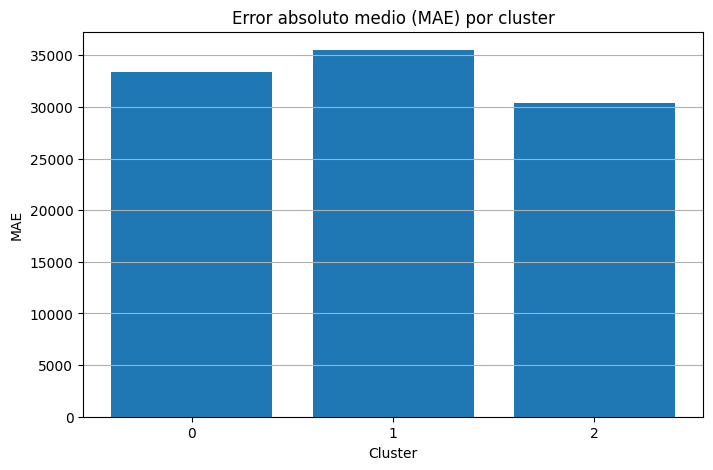

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(errores_por_cluster.index.astype(str), errores_por_cluster["MAE"])

plt.xlabel("cluster")
plt.ylabel("MAE")
plt.title("error absoluto medio (MAE) por cluster")
plt.grid(axis="y")
plt.show()

Este posiblemente es más interesante. Vamos a seleccionar algunas variables relevantes para comparar el error de predicción, el ingreso mediano y el valor mediano de vivienda por cluster. Para poder comparar estas variables en una misma escala, aplicaremos una normalización min-max. Esto nos permitirá visualizar de manera más clara las diferencias entre los clusters en términos de error de predicción. 

In [49]:
import matplotlib.pyplot as plt

# seleccionamos variables relevantes
heatmap_data = errores_por_cluster[[
    "MAE",
    "RMSE",
    "ingreso_promedio",
    "valor_real_promedio"
]].copy()

# normalización min-max para poder comparar escalas distintas
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

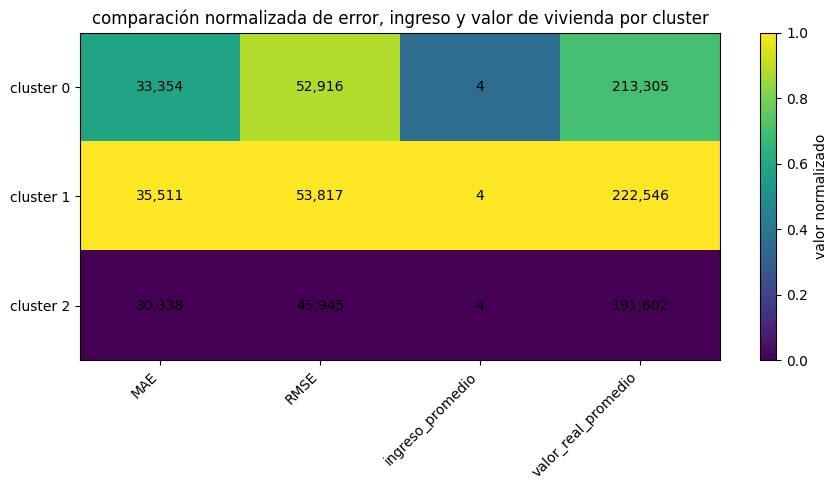

In [50]:
plt.figure(figsize=(9, 5))
plt.imshow(heatmap_norm, aspect="auto")

plt.xticks(
    range(len(heatmap_norm.columns)),
    heatmap_norm.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heatmap_norm.index)),
    [f"cluster {i}" for i in heatmap_norm.index]
)

plt.colorbar(label="valor normalizado")
plt.title("comparación normalizada de error, ingreso y valor de vivienda por cluster")

# agregar valores originales como texto
for i in range(heatmap_norm.shape[0]):
    for j in range(heatmap_norm.shape[1]):
        valor_original = heatmap_data.iloc[i, j]
        plt.text(
            j,
            i,
            f"{valor_original:,.0f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

La visualización normalizada permite comparar simultáneamente los errores de predicción y algunas características socioeconómicas de cada perfil. Se observa que el cluster 1 presenta los valores más altos de MAE y RMSE, junto con el mayor ingreso promedio y el mayor valor real promedio de vivienda. Esto sugiere que los distritos con mayor valorización habitacional tienden a ser más difíciles de predecir con las variables disponibles.

El cluster 0 presenta errores intermedios, con un MAE de aproximadamente 33.354 y un RMSE de 52.916. Además, posee un valor real promedio de vivienda relativamente alto, cercano a 213.305, aunque menor que el del cluster 1. Esto indica que el modelo tiene un desempeño moderado en este perfil, que corresponde principalmente a distritos cercanos al océano.

Por otro lado, el cluster 2 presenta los menores errores de predicción, con un MAE de aproximadamente 30.338 y un RMSE de 45.945. Este cluster también tiene el menor valor real promedio de vivienda, cercano a 191.602. Esto sugiere que el modelo predice con mayor precisión los distritos de menor valorización habitacional relativa.

Los errores son mayores en el perfil con mayor valor promedio de vivienda y menores en el perfil de menor valorización. Por lo tanto, existen diferencias relevantes asociadas a factores territoriales, socioeconómicos y habitacionales capturados por los clusters.